In [1]:
import sys
print(sys.executable)

C:\Users\Hameem\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [2]:
%matplotlib inline
import brian2 as b2
import matplotlib.pyplot as plt
import numpy as np
#from neurodynex3.leaky_integrate_and_fire import LIF
#rom neurodynex3.tools import input_factory, plot_tools


# parameters in SI units: volts, seconds, ohms, amps
V_rest  = -0.070    # -70 mV
V_reset = -0.065    # -65 mV
V_th    = -0.050    # -50 mV  firing threshold
R       = 10e6      # 10 MΩ
tau     = 8e-3      # 8 ms  membrane time constant
t_refr  = 2e-3      # 2 ms  absolute refractory period
dt = 1e-4;

def simulate_lif(I, dt, V_rest,V_reset,V_th, R, tau, t_refr):
    #simulate LIF model through differential equation itself
    n = len(I)
    V=np.zeros(n)
    V[0] = V_rest
    spike_times = []
    refr_steps = int(round(t_refr / dt))   # how many steps to stay clamped
    refr_counter = 0                       # >0 means we're inside refractory

    for k in range(n-1):
        if refr_counter>0:
            V[k+1] = V_reset
            refr_counter -= 1
            continue 
        #differential equation
        dV = (dt / tau) * (-(V[k] - V_rest) + R * I[k])
        V[k+1] = V[k] + dV

        # record spike timings 

        if V[k] < V_th and V[k+1] >= V_th:
            spike_times.append((k+1) * dt)
            V[k+1] = V_reset #reset
            refr_counter = refr_steps
    t = np.arange(n)* dt 
    return t, V, spike_times

def make_pulse_train(n, dt, amplitude, pulse_width, period, t_start):
    #start with zero, then between two steps we switch current on for w steps, for a period, then off
    I = np.zeros(n)
    w     = int(round(pulse_width / dt))   # pulse width in steps
    p     = int(round(period / dt))        # period in steps
    start = int(round(t_start / dt))
    for k0 in range(start, n, p):          # k0 = start of each pulse
        I[k0:k0 + w] = amplitude
    return I

def make_repeated_pattern(pattern, n_repeats, gap_steps=0):
    """
    pick 5 random current values, hold each one for 2ms each (how does that get 20?) creating pattern to be one short random staircase waveform
    """
    gap = np.zeros(gap_steps)
    blocks = []
    for _ in range(n_repeats):
        blocks.append(pattern)
        blocks.append(gap)
    return np.concatenate(blocks)

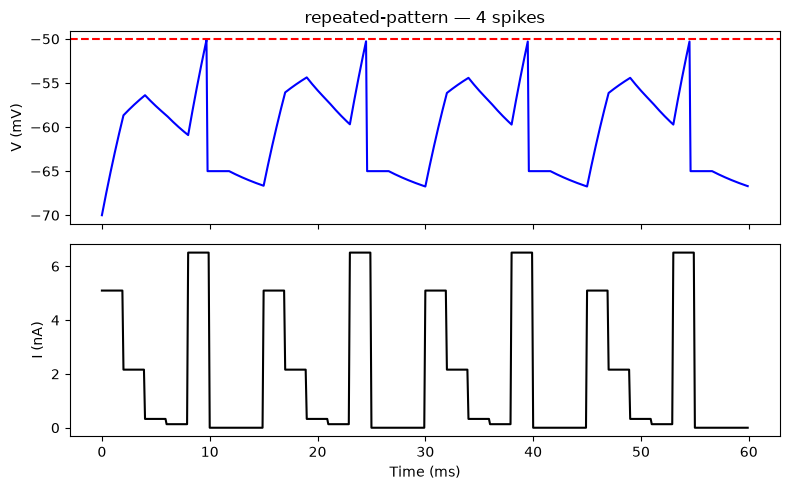

In [3]:
# Demonstration: LIF response to a repeated staircase current pattern
# 5 random amplitudes held for 2ms each, repeated 4 times with 5ms gaps
# Shows the neuron responds consistently to the same pattern each repetition

rng = np.random.default_rng(0)
pattern = np.repeat(rng.uniform(0, 8e-9, size=5), int(round(2e-3/dt)))  # 5 steps × 2 ms each
I_rep = make_repeated_pattern(pattern, n_repeats=4, gap_steps=int(round(5e-3/dt)))
t, V, spikes = simulate_lif(I_rep, dt, V_rest, V_reset, V_th, R, tau, t_refr)

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(t*1000, V*1000, 'b'); ax[0].axhline(-50, ls='--', color='r')
ax[0].set_ylabel("V (mV)"); ax[0].set_title(f"repeated-pattern — {len(spikes)} spikes")
ax[1].plot(t*1000, I_rep*1e9, 'k'); ax[1].set_ylabel("I (nA)"); ax[1].set_xlabel("Time (ms)")
plt.tight_layout(); plt.show()

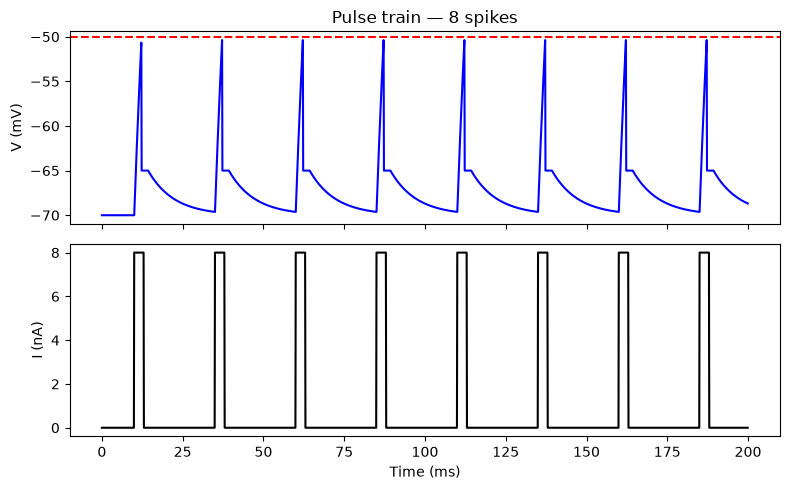

In [10]:
# Demonstration: LIF response to a periodic pulse train
# 8nA pulses of 3ms width, repeated every 25ms
# Shows reliable spike generation on each suprathreshold pulse

T = 0.2;  n = int(round(T/dt))
I_pt = make_pulse_train(n, dt, amplitude=8e-9, pulse_width=3e-3,
                        period=25e-3, t_start=0.01)
t, V, spikes = simulate_lif(I_pt, dt, V_rest, V_reset, V_th, R, tau, t_refr)

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(t*1000, V*1000, 'b'); ax[0].axhline(-50, ls='--', color='r')
ax[0].set_ylabel("V (mV)"); ax[0].set_title(f"Pulse train — {len(spikes)} spikes")
ax[1].plot(t*1000, I_pt*1e9, 'k'); ax[1].set_ylabel("I (nA)"); ax[1].set_xlabel("Time (ms)")
plt.tight_layout(); plt.show()

number of spikes: 0


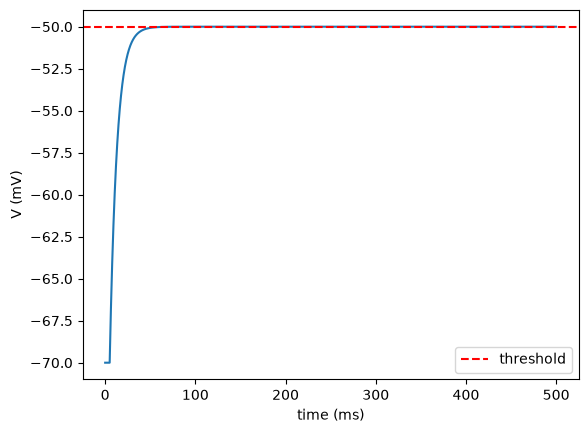

✓ Test 1 passed: no spike at I_min
✓ Test 2 passed: 18 spikes, all reset correctly to V_reset


In [5]:
# ── CELL 1: Validation tests (assertions) ──────────────────────────────

# Test 1: subthreshold
T = 0.5; dt = 1e-4; n = int(round(T/dt))
I_sub = np.zeros(n); I_sub[int(0.005/dt):] = 2e-9       # exactly I_min
t, V, spikes = simulate_lif(I_sub, dt, V_rest, V_reset, V_th, R, tau, t_refr)
print("number of spikes:", len(spikes))   # expect 0
plt.plot(t*1000, V*1000)
plt.axhline(-50, ls='--', color='r', label='threshold')
plt.xlabel("time (ms)"); plt.ylabel("V (mV)"); plt.legend()
plt.show()
print("✓ Test 1 passed: no spike at I_min")



# Test 2 - calculating how many spikes 5nA causes, and whether they reset to V_RESET
T = 0.1; dt = 1e-4; n = int(round(T/dt))
I_sup = np.zeros(n); I_sup[int(0.005/dt):] = 5e-9      # 5 nA, clearly above I_min
t, V, spikes = simulate_lif(I_sup, dt, V_rest, V_reset, V_th, R, tau, t_refr)

assert len(spikes) > 0, "Expected spikes but got none"
for t_sp in spikes:
    k = int(round(t_sp / dt))
    assert abs(V[k] - V_reset) < 1e-9, f"Reset failed at t={t_sp*1000:.1f} ms"
print(f"✓ Test 2 passed: {len(spikes)} spikes, all reset correctly to V_reset")

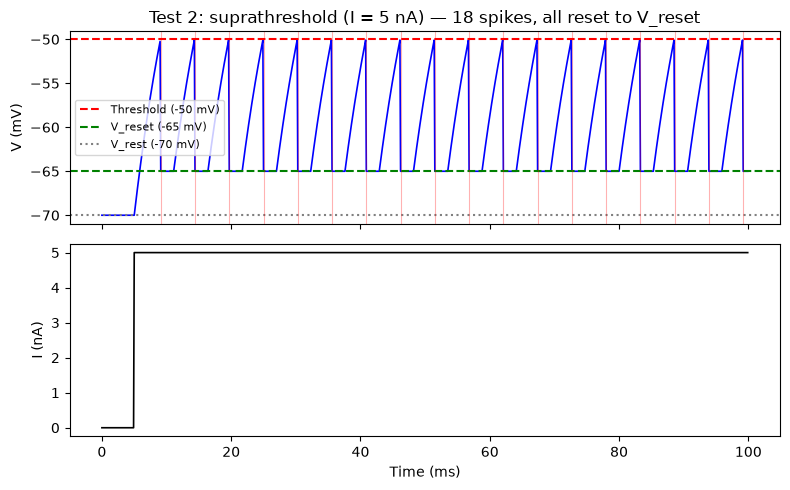

In [6]:
# ── CELL: Plot Test 2 — voltage trace showing spikes + correct reset ───

T = 0.1; dt = 1e-4; n = int(round(T/dt))
I_sup = np.zeros(n); I_sup[int(0.005/dt):] = 5e-9
t_arr, V_arr, spikes = simulate_lif(I_sup, dt, V_rest, V_reset, V_th, R, tau, t_refr)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Top panel: voltage trace
axes[0].plot(t_arr*1000, V_arr*1000, 'b', lw=1.2)
axes[0].axhline(V_th*1000,    ls='--', color='r',  label=f'Threshold ({V_th*1000:.0f} mV)')
axes[0].axhline(V_reset*1000, ls='--', color='g',  label=f'V_reset ({V_reset*1000:.0f} mV)')
axes[0].axhline(V_rest*1000,  ls=':',  color='gray', label=f'V_rest ({V_rest*1000:.0f} mV)')
for t_sp in spikes:
    axes[0].axvline(t_sp*1000, color='r', alpha=0.3, lw=0.8)
axes[0].set_ylabel("V (mV)")
axes[0].set_title(f"Test 2: suprathreshold (I = 5 nA) — {len(spikes)} spikes, all reset to V_reset")
axes[0].legend(fontsize=8)

# Bottom panel: input current
axes[1].plot(t_arr*1000, I_sup*1e9, 'k', lw=1.2)
axes[1].set_ylabel("I (nA)")
axes[1].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()

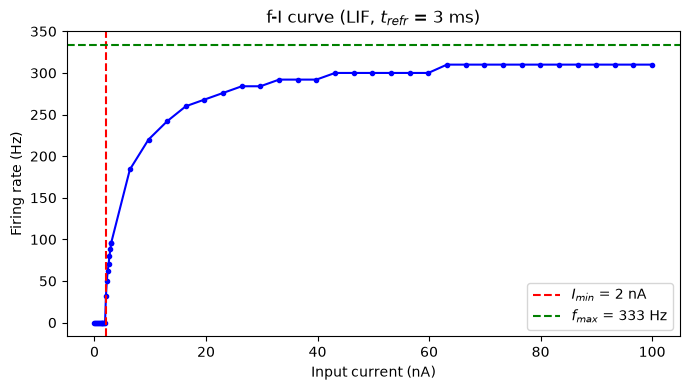

Max observed rate: 310.0 Hz  (theory cap: 333 Hz)


In [7]:
# ── CELL 2: f-I curve (Exercise 1.2) ───────────────────────────────────

T_sim = 0.5          # 500 ms per run
dt    = 1e-4
n     = int(round(T_sim / dt))
t_refr_fi = 3e-3     

# dense near I_min, coarser above
I_values = np.concatenate([
    np.linspace(0, 3e-9, 20),     # fine resolution near rheobase
    np.linspace(3e-9, 100e-9, 30) # coarser above
])

firing_rates = []
for I_amp in I_values:
    I_arr = np.zeros(n)
    I_arr[int(0.005/dt):] = I_amp # build a step current of current amplitude
    _, _, spikes = simulate_lif(I_arr, dt, V_rest, V_reset, V_th, R, tau, t_refr_fi) #simulate neuron output with this current
    firing_rates.append(len(spikes) / T_sim)   # rate is spikes / time

firing_rates = np.array(firing_rates)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(I_values * 1e9, firing_rates, 'b.-')
plt.axvline(2.0, ls='--', color='r', label='$I_{min}$ = 2 nA')
plt.axhline(1/t_refr_fi, ls='--', color='g', label=f'$f_{{max}}$ = {1/t_refr_fi:.0f} Hz')
plt.xlabel("Input current (nA)")
plt.ylabel("Firing rate (Hz)")
plt.title("f-I curve (LIF, $t_{refr}$ = 3 ms)")
plt.legend(); plt.tight_layout()
plt.show()

# Sanity check
print(f"Max observed rate: {firing_rates.max():.1f} Hz  (theory cap: {1/t_refr_fi:.0f} Hz)")

In [9]:
# applying dt convergence sweep to see what time step gives the most optimal results

T = 0.06        # 60 ms, enough to see ~10 spikes at 5 nA
I_amp = 5e-9    # well above rheobase, so spikes are stable

for d in [4e-4, 2e-4, 1e-4, 5e-5]:   # halving each time
    n = int(round(T / d))
    I = np.zeros(n)
    I[int(round(0.005 / d)):] = I_amp
    t, V, spikes = simulate_lif(I, d, V_rest, V_reset, V_th, R, tau, t_refr)
    print(d, len(spikes), spikes[0] * 1000)

'''
The columns show dt, spike count, and first spike time. Spike count is stable at 10 across all timesteps.
First spike time converges to 9.1 ms as dt decreases, with no further change below dt = 0.1 ms. 
This indicates the simulation has converged: halving dt no longer changes the output, meaning numerical error has become negligible.
dt = 0.1 ms is therefore sufficient to approximate the true solution of the deterministic LIF ODE.

'''


0.0004 10 8.8
0.0002 10 9.2
0.0001 10 9.1
5e-05 10 9.1
